# PyTorch로 구현하는 SVM 문자 분류 실습

- `LinearSVMClassifier`: 선형 SVM 구조(데이터를 직선(초평면)으로 분리하는 것)<br>
SVM은 두 클래스를 가장 잘 나누는 경계선을 찾는다.

예:

O O O O

----------- ← 결정 경계(Hyperplane)

X X X X

이 경계를:

초평면(Hyperplane) 이라고 한다.

- `RBFFeatureSVMClassifier`: RBF 커널 효과를 근사하는 Random Fourier Features + SVM 구조

이 구조는:

RBF 커널 SVM 효과를
PyTorch에서 근사(Approximation)한 구조이다.

핵심:

Random Fourier Features(RFF)

를 사용한다.

* 왜 필요한가?

선형 SVM은:

X O X O X O

같이 복잡하게 섞인 데이터는:

직선으로 분리 불가능하다.

RBF 커널은:

데이터를 고차원 공간으로 변환해서
선형 분리 가능하게 만든다.

대표 수식:

K(x,x
′
)=exp(−γ∣∣x−x
′
∣∣
2
)

의미:

- 가까운 점은 높은 유사도
- 먼 점은 낮은 유사도

* 문제점

진짜 RBF 커널 SVM은계산량이 매우 크다.

특히:

데이터가 많으면 느려진다.

* 해결 방법 → Random Fourier Features

RFF는RBF 커널을 근사한다.

즉:

원본 입력 x

    ↓

랜덤 고차원 변환

    ↓

새로운 feature 공간

    ↓
    
Linear SVM 적용

In [1]:
# ============================================================
# 0. 실습 환경 확인
# ============================================================

# torch는 PyTorch의 핵심 라이브러리입니다.
# 텐서 연산, 자동 미분, 신경망 모델 작성에 사용합니다.
import torch

# torch.nn은 PyTorch에서 모델 계층, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.nn.functional은 활성화 함수, 손실 함수 등을 함수 형태로 제공합니다.
import torch.nn.functional as F

# torch.utils.data는 Dataset, DataLoader를 제공하여 데이터를 미니배치로 나누어 학습할 수 있게 합니다.
from torch.utils.data import TensorDataset, DataLoader

# pandas는 CSV 파일을 읽고 표 형태 데이터프레임으로 다루기 위해 사용합니다.
import pandas as pd

# numpy는 수치 계산 및 배열 처리를 위해 사용합니다.
import numpy as np

# matplotlib은 학습 결과 그래프를 그리기 위해 사용합니다.
import matplotlib.pyplot as plt

# sklearn의 LabelEncoder는 문자 A~Z 같은 범주형 라벨을 0~25 숫자로 변환합니다.
from sklearn.preprocessing import LabelEncoder, StandardScaler

# sklearn의 confusion_matrix, classification_report는 분류 성능 평가에 사용합니다.
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# os는 파일 경로 존재 여부를 확인하기 위해 사용합니다.
import os

# urllib.request는 Colab에서 데이터 파일이 없을 때 인터넷에서 데이터를 내려받기 위해 사용합니다.
import urllib.request

# random은 파이썬 기본 난수 생성을 제어하기 위해 사용합니다.
import random

# 실행 장치를 설정합니다.
# GPU가 있으면 cuda, 없으면 cpu를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 사용 중인 장치를 출력합니다.
print("사용 장치:", device)

사용 장치: cpu


In [2]:
# ============================================================
# 1. 재현 가능한 실험을 위한 시드 고정
# ============================================================

# 같은 코드를 여러 번 실행해도 가능한 한 비슷한 결과가 나오도록 난수 시드를 고정합니다.
SEED = 12345

# 파이썬 random 모듈의 난수 시드를 고정합니다.
random.seed(SEED)

# numpy 난수 시드를 고정합니다.
np.random.seed(SEED)

# PyTorch CPU 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# GPU가 사용 가능한 경우 GPU 난수 시드도 고정합니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("난수 시드 고정 완료:", SEED)

난수 시드 고정 완료: 12345


## 1단계. 데이터 준비

CSV 파일을 읽습니다.
Colab에서는 `/content/data/opt_letterdata.csv` 위치에 파일이 있으면 그 파일을 사용합니다.  
파일이 없으면 UCI Letter Recognition 데이터셋 형식과 동일한 데이터를 인터넷에서 내려받아 사용합니다.

데이터 컬럼 구조:

- `letter`: 정답 라벨, A~Z
- 나머지 16개 컬럼: 글자 이미지에서 추출된 수치 특징

In [3]:
# ============================================================
# 2. 데이터 파일 준비
# ============================================================

# [Colab 환경 코드]
# DATA_DIR = "/content/data"
# os.makedirs(DATA_DIR, exist_ok=True)
# csv_path = os.path.join(DATA_DIR, "국가데이터처_나라통계_우편번호_20211110.csv")
# df = pd.read_csv(csv_path)

# CSV 파일 경로를 지정합니다.
# 커널 작업 디렉토리는 노트북 파일이 있는 0529-s/ 폴더입니다.
# 따라서 content/data/ 상대 경로로 접근합니다.
csv_path = "국가데이터처_나라통계_우편번호_20211110.csv"

# CSV 파일을 pandas DataFrame으로 읽습니다.
# 한글이 포함된 파일이므로 encoding='cp949'를 지정해야 합니다.
df = pd.read_csv(csv_path, encoding="cp949")

# 데이터 앞부분 5개 행을 출력하여 구조를 확인합니다.
df.head()


,우편번호,우편번호순서,도이름,시군구이름,읍면동이름,리건물이름,동호,전체주소
0,137926,11,서울특별시,서초구,서초1동,NaN,1641-1~1641-13,서울특별시 서초구 서초1동 1641-1~1641-13
1,137927,11,서울특별시,서초구,서초3동,NaN,1451,서울특별시 서초구 서초3동 1451
2,137929,12,서울특별시,서초구,서초4동,서초교대e편한세상아파트,(101~106동),서울특별시 서초구 서초4동 서초교대e편한세상아파트 (101~106동)
3,137930,2,서울특별시,서초구,반포1동,반포자이아파트,(101~144동),서울특별시 서초구 반포1동 반포자이아파트 (101~144동)
4,137931,2,서울특별시,서초구,반포1동,삼호가든아파트,(501~503동),서울특별시 서초구 반포1동 삼호가든아파트 (501~503동)


In [4]:
# ============================================================
# 3. 데이터 구조 확인
# ============================================================

# 데이터 행과 열의 개수를 확인합니다.
print("데이터 크기:", df.shape)

# 각 컬럼의 자료형과 결측치 여부를 확인합니다.
print("\n데이터 정보:")
print(df.info())

# 우편번호 고유 개수와 결측치를 확인합니다.
# [이전 코드 - letter 컬럼 기반]
print("\n우편번호 :")
print(df["우편번호"].value_counts().sort_index())
print("\n우편번호 고유 개수:")
print(df["우편번호"].nunique(), '개')
print("\n컬럼별 결측치:")
print(df.isnull().sum())



데이터 크기: (52543, 8)

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52543 entries, 0 to 52542
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   우편번호    52543 non-null  int64 
 1   우편번호순서  52543 non-null  int64 
 2   도이름     52543 non-null  object
 3   시군구이름   52543 non-null  object
 4   읍면동이름   52177 non-null  object
 5   리건물이름   32422 non-null  object
 6   동호      20961 non-null  object
 7   전체주소    52543 non-null  object
dtypes: int64(2), object(6)
memory usage: 3.2+ MB
None

우편번호 :
우편번호
100011    1
100012    1
100013    1
100014    1
100015    1
         ..
799813    1
799820    1
799821    5
799822    3
799823    1
Name: count, Length: 31723, dtype: int64

우편번호 고유 개수:
31723 개

컬럼별 결측치:
우편번호          0
우편번호순서        0
도이름           0
시군구이름         0
읍면동이름       366
리건물이름     20121
동호        31582
전체주소          0
dtype: int64


In [5]:

# ============================================================
# 3-1. 우편번호 자리별 주소 연관성 분석
# ============================================================
# 우편번호 6자리 각각이 주소 계층(도이름, 시군구이름)과 어떻게 연관되는지 살펴봅니다.

d1 = df["우편번호"] // 100000           # 첫째 자리 (1~7)
d2 = (df["우편번호"] // 10000) % 10    # 둘째 자리 (0~9)

# ── 첫째 자리 vs 도이름 ──
print("=" * 70)
print("▶ 우편번호 첫째 자리(1~7) vs 도이름")
print("  → 첫째 자리 하나만으로 도/광역시를 거의 완벽하게 구분합니다.")
print("=" * 70)
cross1 = pd.crosstab(d1, df["도이름"])
cross1.index.name = "첫째자리"
# 열 이름을 4글자로 줄여서 폭을 맞춥니다.
cross1.columns = [c[:5] for c in cross1.columns]
print(cross1.to_string())

# ── 첫째 자리 구간(0-3 / 4-7 / 8-9) vs 도이름 ──
print("\n" + "=" * 70)
print("▶ 첫째 자리를 구간으로 묶기: 0-3 / 4-7 / 8-9")
print("  → 구간만으로도 광역 지역권을 분리할 수 있습니다.")
print("=" * 70)
d1_range = d1.apply(lambda x: "0-3" if x <= 3 else ("4-7" if x <= 7 else "8-9"))
cross_r = pd.crosstab(d1_range, df["도이름"])
cross_r.index.name = "구간"
cross_r.columns = [c[:5] for c in cross_r.columns]
print(cross_r.to_string())

# ── 앞 2자리 조합 → 대표 도이름 ──
print("\n" + "=" * 70)
print("▶ 앞 2자리 조합(d1, d2) → 대표 도이름 매핑")
print("  → 앞 2자리만 알면 어느 도인지 거의 1:1로 알 수 있습니다.")
print("=" * 70)
top_map = (df.assign(앞2자리=(d1.astype(str) + d2.astype(str)).str.zfill(2))
             .groupby("앞2자리")["도이름"]
             .agg(lambda x: x.value_counts().index[0])
             .reset_index())
top_map.columns = ["앞 2자리", "대표 도이름"]
print(top_map.to_string(index=False))


▶ 우편번호 첫째 자리(1~7) vs 도이름
  → 첫째 자리 하나만으로 도/광역시를 거의 완벽하게 구분합니다.
       강원도   경기도  경상남도  경상북도  광주광역시  대구광역시  대전광역시  부산광역시  서울특별시  세종특별자  울산광역시  인천광역시  전라남도  전라북도  제주특별자  충청남도  충청북도
첫째자리                                                                                                               
1        0     0     0     0      0      0      0      0   8112      0      0      0     0     0      0     0     0
2     3017     0     0     0      0      0      0      0      0      0      0      0     0     0      0     0     0
3        0     0     0     0      0      0    957      0      0    182      0      0     0     0      0  3090  2358
4       17  8701     0     0      0      0      0      0      1      0      0   1616     0     0      0     0     0
5        0     0     0     0   1367      0      0      0      0      0      0      0  3859  2906      0     0     0
6        0     0  3695     0      0      0      0   3600      0      0    825      0     0     0    480     0     0
7        

## 2단계. 우편번호 자리 분해 및 분류 대상 설정

**새로운 접근 방식**: 우편번호 → 주소 역방향 예측

한국 우편번호 6자리는 각 자리 숫자(0~9)가 지리 계층을 직접 인코딩합니다.

| 방식 | 설명 | 문제점 |
|------|------|-------|
| 원본 숫자 그대로 (`d1=1, d2=3, ...`) | SVM이 숫자를 수직선으로 봄 | `d1=1`(서울)과 `d1=2`(부산)가 "거리 1"로 인식됨 → 거짓 순서 가정 |
| **원-핫 인코딩** (`d1_1=1, d1_2=0, ...`) | 각 숫자를 독립 이진 특징으로 변환 | **없음 → 올바른 범주형 처리** |

#### 원-핫 인코딩 방식

각 자리 숫자(0~9) → 10개의 이진 특징:

```
d1 = 1(서울) → [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
d1 = 4(경기) → [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
```

- `X` (입력): 6자리 × 10개 이진값 = **최대 60개 특징**  
  (실제로는 각 자리에 등장하는 숫자 종류만큼만 생성됨)
- `y` (정답): **도이름** (17개 클래스)


In [6]:

# ============================================================
# 4. 입력 X와 정답 y 분리
# ============================================================

# [이전 코드 - UCI letter 데이터 기반]
# y_text = df["letter"].values
# X = df.drop(columns=["letter"]).values
# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y_text)
# num_classes = len(label_encoder.classes_)
# num_features = X.shape[1]

# [이전 코드 - 우편번호 전체(31,723개 클래스) 분류 → 정확도 0.7% 실패]
# 원인: 클래스가 너무 많고, LabelEncoder 정수는 지리 거리와 무관 → SVM 학습 불가능.

# [이전 코드 - 주소 컬럼 → 우편번호 앞 2자리 분류 (61개 클래스, 정확도 ~26%)]
# 원인: 주소 컬럼의 LabelEncoder 정수값도 지리 의미가 없어 SVM 경계 학습이 어려움.

# [이전 코드 - 6자리 원본 숫자 = 6개 특징 → 정확도 97.99%]
# 문제: SVM은 숫자 값을 수직선 위의 점으로 봄.
#   예) d1=1(서울)과 d1=2(부산)를 "거리 1"로, d1=1과 d1=9를 "거리 8"로 해석.
#   즉, 숫자가 가까우면 지리적으로도 가깝다는 거짓 순서(가정)가 생김.
#   우편번호 자리 숫자는 순서 없는 범주형 값이므로, 연속값처럼 다루면 정보 손실이 발생함.

# ================================================================
# 개선: 원-핫 인코딩(One-Hot Encoding) 적용
#
# 각 자리 숫자(0~9)를 10개의 이진 특징으로 변환합니다.
#   예) d1=1(서울) → [0,1,0,0,0,0,0,0,0,0]
#       d1=4(경기) → [0,0,0,0,1,0,0,0,0,0]
#
# 이렇게 하면:
#   - d1=1과 d1=4 사이에 거짓 순서 관계가 생기지 않음
#   - Linear SVM이 각 숫자 값마다 독립적인 결정 경계를 학습 가능
#   - 6자리 × 10값 = 60개 이진 특징
# ================================================================

from sklearn.preprocessing import OneHotEncoder

# 우편번호를 6개 자리 숫자로 분해합니다.
df["zip_d1"] = df["우편번호"] // 100000           # 첫째 자리 (1~7)
df["zip_d2"] = (df["우편번호"] // 10000) % 10     # 둘째 자리 (0~9)
df["zip_d3"] = (df["우편번호"] // 1000)  % 10     # 셋째 자리 (0~9)
df["zip_d4"] = (df["우편번호"] // 100)   % 10     # 넷째 자리 (0~9)
df["zip_d5"] = (df["우편번호"] // 10)    % 10     # 다섯째 자리 (0~9)
df["zip_d6"] =  df["우편번호"]           % 10     # 여섯째 자리 (0~9)

digit_cols = [f"zip_d{i}" for i in range(1, 7)]

# OneHotEncoder로 각 자리를 10개 이진 특징으로 변환합니다.
# categories='auto'는 실제 데이터에 나타난 값으로 범주를 자동 결정합니다.
# sparse_output=False는 결과를 일반 numpy 배열로 반환합니다.
ohe = OneHotEncoder(sparse_output=False, dtype=np.float32)
X = ohe.fit_transform(df[digit_cols])

# 생성된 특징 이름 확인 (예: zip_d1_1, zip_d1_2, ...)
feature_cols = ohe.get_feature_names_out(digit_cols).tolist()

# 정답 y: 도이름 (17개 클래스)
le_do = LabelEncoder()
y = le_do.fit_transform(df["도이름"]).astype(np.int64)

num_classes  = len(le_do.classes_)
num_features = X.shape[1]
class_names  = list(le_do.classes_)

print("입력 특징 수:", num_features, "(6자리 × 각 자리 원-핫 인코딩)")
print("클래스 수 (도이름):", num_classes)
print("도이름 목록:", class_names)
print("\n특징 예시 (첫 3개):", feature_cols[:3], "...")



입력 특징 수: 57 (6자리 × 각 자리 원-핫 인코딩)
클래스 수 (도이름): 17
도이름 목록: ['강원도', '경기도', '경상남도', '경상북도', '광주광역시', '대구광역시', '대전광역시', '부산광역시', '서울특별시', '세종특별자치시', '울산광역시', '인천광역시', '전라남도', '전라북도', '제주특별자치도', '충청남도', '충청북도']

특징 예시 (첫 3개): ['zip_d1_1', 'zip_d1_2', 'zip_d1_3'] ...


## 3단계. 훈련 데이터와 테스트 데이터 분리
```
opt_letters_train <- opt_letters[1:16000, ]
opt_letters_test  <- opt_letters[16001:20000, ]
```

즉, 앞의 16,000개는 훈련용, 뒤의 4,000개는 테스트용으로 사용합니다.

In [7]:
# ============================================================
# 5. 훈련 데이터와 테스트 데이터 분리
# ============================================================

# [이전 코드 - 고정 인덱스 방식]
# X_train = X[:16000]
# y_train = y[:16000]
# X_test = X[16000:]
# y_test = y[16000:]

# sklearn의 train_test_split을 사용하여 무작위로 분리합니다.
from sklearn.model_selection import train_test_split

# 전체 데이터의 20%를 테스트용으로 사용합니다.
# random_state=SEED를 지정하여 매번 같은 결과가 나오도록 합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("훈련 X:", X_train.shape)
print("훈련 y:", y_train.shape)
print("테스트 X:", X_test.shape)
print("테스트 y:", y_test.shape)


훈련 X: (42034, 57)
훈련 y: (42034,)
테스트 X: (10509, 57)
테스트 y: (10509,)


## 4단계. 데이터 정규화

SVM은 경계와 거리 개념을 사용하는 알고리즘이므로 입력 특징의 스케일이 중요합니다.  
따라서 평균 0, 표준편차 1이 되도록 표준화합니다.

주의:

- 훈련 데이터로만 `fit`
- 테스트 데이터는 훈련 데이터 기준으로 `transform`

이렇게 해야 테스트 데이터 정보가 학습에 새어 들어가지 않습니다.

In [8]:
# ============================================================
# 6. 표준화 전처리
# ============================================================

# StandardScaler는 각 특징을 평균 0, 표준편차 1로 변환합니다.
scaler = StandardScaler()

# 훈련 데이터의 평균과 표준편차를 학습하고 동시에 변환합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 훈련 데이터에서 학습한 평균과 표준편차로만 변환합니다.
X_test_scaled = scaler.transform(X_test)

# numpy 배열을 PyTorch 텐서로 변환합니다.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)

# 훈련 정답도 PyTorch 텐서로 변환합니다.
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

# 테스트 입력을 PyTorch 텐서로 변환합니다.
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# 테스트 정답을 PyTorch 텐서로 변환합니다.
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("PyTorch 텐서 변환 완료")
print(X_train_tensor.shape, y_train_tensor.shape)

PyTorch 텐서 변환 완료
torch.Size([42034, 57]) torch.Size([42034])


In [9]:
# ============================================================
# 7. DataLoader 생성
# ============================================================

# TensorDataset은 입력 텐서와 정답 텐서를 하나의 데이터셋으로 묶어줍니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader는 데이터를 batch_size 단위로 나누어 모델에 공급합니다.
train_loader = DataLoader(
    train_dataset,       # 학습에 사용할 데이터셋입니다.
    batch_size=256,      # 한 번에 256개 샘플씩 학습합니다.
    shuffle=True         # 매 epoch마다 데이터 순서를 섞어 학습 안정성을 높입니다.
)

print("미니배치 개수:", len(train_loader))

미니배치 개수: 165


## 5단계. PyTorch SVM 모델 클래스 작성

전통적인 SVM은 다음과 같은 결정 경계를 학습합니다.

```text
wᵀx + b = 0
```

다중 클래스 분류에서는 클래스마다 하나의 점수(score)를 계산하고, 가장 큰 점수를 가진 클래스(category)를 예측합니다.

여기서는 `nn.Linear`를 사용하여 선형 결정 경계를 만들고,  
손실 함수는 다중 클래스 SVM의 hinge loss를 직접 작성합니다.

In [10]:
# ============================================================
# 8. 다중 클래스 SVM 손실 함수 정의
# ============================================================

class MultiClassHingeLoss(nn.Module):
    # nn.Module을 상속하여 PyTorch 손실 함수 클래스를 만듭니다.
    def __init__(self, margin=1.0):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # margin은 정답 클래스 점수가 다른 클래스보다 최소한 얼마나 커야 하는지를 의미합니다.
        self.margin = margin

    def forward(self, scores, targets):
        # scores: 모델이 출력한 클래스별 점수, 크기 [batch_size, num_classes]
        # targets: 실제 정답 클래스 번호, 크기 [batch_size]

        # 배치 데이터 개수를 가져옵니다.
        batch_size = scores.size(0)

        # 각 샘플의 정답 클래스 점수만 뽑아냅니다.
        correct_scores = scores[torch.arange(batch_size), targets].view(-1, 1)

        # SVM hinge loss 계산식입니다.
        # 정답이 아닌 클래스 점수 - 정답 클래스 점수 + margin 이 0보다 크면 손실이 발생합니다.
        margins = torch.clamp(scores - correct_scores + self.margin, min=0.0)

        # 정답 클래스 자체에 대한 margin은 손실에서 제외해야 하므로 0으로 만듭니다.
        margins[torch.arange(batch_size), targets] = 0.0

        # 모든 샘플과 클래스에 대한 평균 손실을 반환합니다.
        loss = margins.sum(dim=1).mean()

        return loss

In [11]:
# ============================================================
# 9. 선형 SVM 모델 클래스 정의
# ============================================================

class LinearSVMClassifier(nn.Module):
    # nn.Module을 상속하여 PyTorch 모델 클래스를 작성합니다.
    def __init__(self, input_dim, num_classes):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # 선형 계층입니다.
        # 입력 특징 수 input_dim을 클래스 수 num_classes 점수로 변환합니다.
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # forward는 모델이 입력 x를 받아 출력 scores를 만드는 함수입니다.
        # 여기서 scores는 확률이 아니라 클래스(category)별 점수입니다.
        scores = self.linear(x)

        # 계산된 클래스별 점수를 반환합니다.
        return scores

## 6단계. 학습 함수 작성

머신러닝 전체 흐름에서 학습 단계는 다음 과정을 반복합니다.

1. 모델에 입력 데이터를 넣어 예측 점수 계산
2. 손실 함수로 오차 계산
3. `backward()`로 기울기 계산
4. optimizer로 파라미터 업데이트

In [12]:
# ============================================================
# 10. 모델 학습 함수 정의
# ============================================================

def train_model(model, train_loader, criterion, optimizer, epochs=30, l2_lambda=0.0):
    # model: 학습할 PyTorch 모델입니다.
    # train_loader: 미니배치 단위로 데이터를 공급하는 DataLoader입니다.
    # criterion: 손실 함수입니다.
    # optimizer: 모델 파라미터를 업데이트하는 최적화 알고리즘입니다.
    # epochs: 전체 데이터를 몇 번 반복 학습할지 정합니다.
    # l2_lambda: SVM의 C와 반대 성격에 가까운 L2 규제 강도입니다.

    # epoch별 평균 손실을 저장할 리스트입니다.
    loss_history = []

    # 모델을 학습 모드로 전환합니다.
    model.train()

    # 지정된 epoch 수만큼 반복합니다.
    for epoch in range(epochs):
        # 한 epoch 동안의 손실 합계를 저장합니다.
        total_loss = 0.0

        # DataLoader에서 미니배치 데이터를 하나씩 꺼냅니다.
        for batch_X, batch_y in train_loader:
            # 입력 데이터를 GPU 또는 CPU 장치로 이동합니다.
            batch_X = batch_X.to(device)

            # 정답 데이터를 GPU 또는 CPU 장치로 이동합니다.
            batch_y = batch_y.to(device)

            # 이전 배치에서 계산된 기울기를 초기화합니다.
            optimizer.zero_grad()

            # 모델에 입력 데이터를 넣어 클래스별 점수를 계산합니다.
            scores = model(batch_X)

            # SVM hinge loss를 계산합니다.
            loss = criterion(scores, batch_y)

            # L2 규제 항을 추가합니다.
            # SVM은 마진 최대화를 위해 가중치 크기를 제어하는 규제를 사용합니다.
            if l2_lambda > 0:
                l2_norm = sum(torch.sum(param ** 2) for param in model.parameters())
                loss = loss + l2_lambda * l2_norm

            # 손실에 대한 기울기를 자동 계산합니다.
            loss.backward()

            # 계산된 기울기를 이용해 모델 파라미터를 업데이트합니다.
            optimizer.step()

            # 현재 배치 손실을 누적합니다.
            total_loss += loss.item()

        # 한 epoch의 평균 손실을 계산합니다.
        avg_loss = total_loss / len(train_loader)

        # 평균 손실을 리스트에 저장합니다.
        loss_history.append(avg_loss)

        # 5 epoch마다 학습 상황을 출력합니다.
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # 학습 손실 기록을 반환합니다.
    return loss_history

In [13]:
# ============================================================
# 11. 평가 함수 정의
# ============================================================

def evaluate_model(model, X_tensor, y_tensor):
    # model: 평가할 PyTorch 모델입니다.
    # X_tensor: 평가 입력 데이터입니다.
    # y_tensor: 실제 정답 데이터입니다.

    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 평가에서는 기울기를 계산할 필요가 없으므로 no_grad를 사용합니다.
    with torch.no_grad():
        # 입력 데이터를 장치로 이동합니다.
        X_tensor = X_tensor.to(device)

        # 모델이 클래스별 점수를 출력합니다.
        scores = model(X_tensor)

        # 가장 높은 점수를 가진 클래스 번호를 예측값으로 선택합니다.
        preds = torch.argmax(scores, dim=1)

        # 예측값을 CPU numpy 배열로 변환합니다.
        preds_np = preds.cpu().numpy()

        # 실제 정답도 numpy 배열로 변환합니다.
        y_np = y_tensor.cpu().numpy()

        # 정확도를 계산합니다.
        acc = accuracy_score(y_np, preds_np)

    # 정확도와 예측 결과를 반환합니다.
    return acc, preds_np

## 7단계. 선형 SVM 학습

선형 SVM:

```
letter_classifier <- ksvm(letter ~ ., data = opt_letters_train, kernel = "vanilladot")
```

PyTorch 변환:

- `LinearSVMClassifier`
- `MultiClassHingeLoss`
- `Adam` optimizer
- L2 규제 적용

In [14]:
# ============================================================
# 12. 선형 SVM 모델 생성 및 학습
# ============================================================

# 선형 SVM 모델 객체를 생성합니다.
linear_svm = LinearSVMClassifier(
    input_dim=num_features,     # 입력 특징 개수입니다.
    num_classes=num_classes     # 분류할 클래스 개수입니다.
).to(device)

# 다중 클래스 hinge loss 객체를 생성합니다.
criterion = MultiClassHingeLoss(margin=1.0)

# Adam optimizer를 사용하여 모델 파라미터를 업데이트합니다.
optimizer = torch.optim.Adam(
    linear_svm.parameters(),    # 학습할 모델 파라미터입니다.
    lr=0.01                     # 학습률입니다.
)

# 선형 SVM 모델을 학습합니다.
linear_loss_history = train_model(
    model=linear_svm,           # 학습할 모델입니다.
    train_loader=train_loader,  # 훈련 데이터 로더입니다.
    criterion=criterion,        # SVM 손실 함수입니다.
    optimizer=optimizer,        # 최적화 알고리즘입니다.
    epochs=50,                  # 전체 데이터를 50번 반복 학습합니다.
    l2_lambda=1e-4              # L2 규제 강도입니다.
)

Epoch [5/50], Loss: 0.0034
Epoch [10/50], Loss: 0.0030
Epoch [15/50], Loss: 0.0031
Epoch [20/50], Loss: 0.0032
Epoch [25/50], Loss: 0.0038
Epoch [30/50], Loss: 0.0037
Epoch [35/50], Loss: 0.0038
Epoch [40/50], Loss: 0.0044
Epoch [45/50], Loss: 0.0046
Epoch [50/50], Loss: 0.0072


In [15]:

# ============================================================
# 13. 선형 SVM 평가
# ============================================================

# 테스트 데이터로 선형 SVM 모델 성능을 평가합니다.
linear_acc, linear_preds = evaluate_model(linear_svm, X_test_tensor, y_test_tensor)

# 정확도를 출력합니다.
print(f"선형 SVM 테스트 정확도: {linear_acc:.4f}")

# [이전 코드 - letter 라벨 변환]
# linear_pred_letters = label_encoder.inverse_transform(linear_preds)
# print("예측 문자 일부:", linear_pred_letters[:20])

# [이전 코드 - 우편번호 라벨 변환]
# linear_pred_zips = le_zip.inverse_transform(linear_preds)
# print("예측 우편번호 일부:", linear_pred_zips[:20])

# 숫자 예측값을 도이름 라벨로 다시 변환합니다.
linear_pred_do = le_do.inverse_transform(linear_preds)

# 예측 결과 일부를 출력합니다.
print("예측 도이름 일부:", linear_pred_do[:20])


선형 SVM 테스트 정확도: 0.9996
예측 도이름 일부: ['인천광역시' '충청북도' '서울특별시' '경기도' '경기도' '강원도' '경상남도' '광주광역시' '대전광역시' '서울특별시'
 '서울특별시' '경기도' '경상남도' '대전광역시' '대전광역시' '경상남도' '인천광역시' '전라남도' '강원도' '경상북도']


In [16]:

# ============================================================
# 14. 선형 SVM 혼동 행렬 분석
# ============================================================

# 도이름 클래스가 17개이므로 17×17 전체 혼동 행렬을 출력합니다.
# (이전에는 클래스가 31,723개라 Top 10 요약만 가능했습니다.)
cm_linear = confusion_matrix(y_test, linear_preds, labels=np.arange(num_classes))

# [이전 코드 - Top 10 요약 (클래스 수가 너무 많을 때 사용)]
# temp_cm = cm_linear.copy()
# np.fill_diagonal(temp_cm, 0)
# sorted_indices = np.argsort(temp_cm.ravel())[::-1][:10]
# rows, cols = np.unravel_index(sorted_indices, temp_cm.shape)

# 17×17 혼동 행렬을 DataFrame으로 출력합니다.
cm_linear_df = pd.DataFrame(
    cm_linear,
    index=class_names,
    columns=class_names
)
print("선형 SVM 혼동 행렬 (행=실제, 열=예측)")
print(cm_linear_df.to_string())

# 대각선(정답)을 0으로 만들어 오답 사례 Top 10도 함께 표시합니다.
temp_cm = cm_linear.copy()
np.fill_diagonal(temp_cm, 0)

top_n = 10
sorted_indices = np.argsort(temp_cm.ravel())[::-1][:top_n]
rows, cols = np.unravel_index(sorted_indices, temp_cm.shape)

top_confused_df = pd.DataFrame({
    "실제 도이름": np.array(class_names)[rows],
    "예측 도이름": np.array(class_names)[cols],
    "혼동 횟수":   temp_cm[rows, cols]
})
print("\n선형 SVM - 가장 많이 혼동된 도이름 쌍 Top 10")
top_confused_df


선형 SVM 혼동 행렬 (행=실제, 열=예측)
         강원도   경기도  경상남도  경상북도  광주광역시  대구광역시  대전광역시  부산광역시  서울특별시  세종특별자치시  울산광역시  인천광역시  전라남도  전라북도  제주특별자치도  충청남도  충청북도
강원도      611     4     0     0      0      0      0      0      0        0      0      0     0     0        0     0     0
경기도        0  1737     0     0      0      0      0      0      0        0      0      0     0     0        0     0     0
경상남도       0     0   740     0      0      0      0      0      0        0      0      0     0     0        0     0     0
경상북도       0     0     0  1004      0      0      0      0      0        0      0      0     0     0        0     0     0
광주광역시      0     0     0     0    269      0      0      0      0        0      0      0     0     0        0     0     0
대구광역시      0     0     0     0      0    596      0      0      0        0      0      0     0     0        0     0     0
대전광역시      0     0     0     0      0      0    173      0      0        0      0      0     0     0        0     0     

,실제 도이름,예측 도이름,혼동 횟수
0,강원도,경기도,4
1,대구광역시,부산광역시,0
2,대구광역시,서울특별시,0
3,대구광역시,세종특별자치시,0
4,대구광역시,울산광역시,0
5,대구광역시,인천광역시,0
6,대구광역시,전라남도,0
7,대구광역시,전라북도,0
8,대구광역시,대전광역시,0
9,대구광역시,충청남도,0


In [17]:

# ============================================================
# 14-1. 선형 SVM 오답 데이터 원본 확인
# ============================================================
# 예측이 틀린 샘플의 실제 우편번호와 주소 정보를 확인합니다.

# 테스트 인덱스 → 원본 df 인덱스로 역추적합니다.
_, test_indices = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED
)

# 오답 위치 (예측값 ≠ 실제값)
wrong_mask = (linear_preds != y_test)
wrong_test_positions = np.where(wrong_mask)[0]   # 테스트 배열 내 위치
wrong_df_indices = test_indices[wrong_test_positions]  # 원본 df 행 번호

# 원본 데이터에서 해당 행을 가져옵니다.
wrong_rows = df.iloc[wrong_df_indices][["우편번호", "도이름", "시군구이름", "읍면동이름", "전체주소"]].copy()
wrong_rows["예측_도이름"] = le_do.inverse_transform(linear_preds[wrong_test_positions])

print(f"선형 SVM 오답 총 {len(wrong_rows)}건\n")
wrong_rows.reset_index(drop=True)


선형 SVM 오답 총 4건



,우편번호,도이름,시군구이름,읍면동이름,전체주소,예측_도이름
0,487839,강원도,철원군,동송읍,강원도 철원군 동송읍 관우리 사서함 105-16,경기도
1,487839,강원도,철원군,동송읍,강원도 철원군 동송읍 양지리 사서함 105-4,경기도
2,487839,강원도,철원군,동송읍,강원도 철원군 동송읍 오덕2리 사서함 105-20,경기도
3,487839,강원도,철원군,동송읍,강원도 철원군 동송읍 오지리 사서함 105-23,경기도


## 예외 처리: 우편번호 직접 조회 테이블(Lookup Table) 보정

오답 4건의 원인은 **우편번호 자리 패턴과 행정 구역이 불일치**하는 예외 케이스입니다.

- 철원군(강원도)의 우편번호 `487839`는 앞자리(`48xxxx`)가 경기도 권역과 겹침
- SVM은 자리 패턴만 보므로 `48xxxx → 경기도`로 학습 → 예외 케이스를 틀림

### 해결 방법: 메모리 기반 보정 (Lookup Table Override)

```
[모델 예측]
  우편번호 자리 패턴 → SVM → 도이름 예측
       ↓
[보정 단계]
  훈련 데이터에서 해당 우편번호를 본 적 있으면 → 직접 조회 결과로 덮어쓰기
  훈련에 없는 새 우편번호이면              → 모델 예측값 그대로 사용
```

이 방식은 **일반화(모델) + 기억(Lookup)** 을 결합한 실무적 접근법입니다.


In [18]:

# ============================================================
# 14-2. 예외 처리: Lookup Table 보정
# ============================================================

# ── 1단계: 훈련 데이터에서 우편번호 → 도이름 조회 테이블 생성 ──
# test_indices는 셀 14-1에서 이미 생성되어 있습니다.
# 나머지 인덱스를 훈련 인덱스로 사용합니다.
train_indices = np.setdiff1d(np.arange(len(df)), test_indices)
train_df_lookup = df.iloc[train_indices]

# 같은 우편번호가 여러 도에 걸쳐 있으면 다수결로 결정합니다.
zip_lookup = (
    train_df_lookup.groupby("우편번호")["도이름"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)
print(f"훈련 데이터 고유 우편번호 수: {len(zip_lookup):,}개")

# ── 2단계: 테스트 데이터에 보정 적용 ──
test_zip_codes = df.iloc[test_indices]["우편번호"].values

corrected_preds = linear_preds.copy()
lookup_hit   = 0   # 조회 테이블에서 찾은 샘플 수
lookup_miss  = 0   # 훈련에 없어 모델 예측 그대로 사용한 샘플 수
override_fix = 0   # 조회 결과가 모델 예측과 달라 수정된 수

for i, zip_code in enumerate(test_zip_codes):
    if zip_code in zip_lookup:
        do_name = zip_lookup[zip_code]
        corrected_label = le_do.transform([do_name])[0]
        if corrected_preds[i] != corrected_label:
            override_fix += 1          # 모델이 틀린 것을 보정
        corrected_preds[i] = corrected_label
        lookup_hit += 1
    else:
        lookup_miss += 1               # 모델 예측 유지

# ── 3단계: 보정 전후 정확도 비교 ──
corrected_acc = accuracy_score(y_test, corrected_preds)

print(f"\n{'':=<50}")
print(f"  보정 전 정확도: {linear_acc:.4f}  ({int((1-linear_acc)*len(y_test))}건 오답)")
print(f"  보정 후 정확도: {corrected_acc:.4f}  ({int((1-corrected_acc)*len(y_test))}건 오답)")
print(f"{'':=<50}")
print(f"\n  조회 테이블 처리:  {lookup_hit:,}건")
print(f"  모델 예측 유지  :  {lookup_miss:,}건 (훈련에 없는 새 우편번호)")
print(f"  Lookup으로 수정 :  {override_fix}건 (모델이 틀렸던 예외 케이스)")


훈련 데이터 고유 우편번호 수: 26,860개

  보정 전 정확도: 0.9996  (3건 오답)
  보정 후 정확도: 0.9999  (0건 오답)

  조회 테이블 처리:  5,487건
  모델 예측 유지  :  5,022건 (훈련에 없는 새 우편번호)
  Lookup으로 수정 :  5건 (모델이 틀렸던 예외 케이스)


In [19]:
# ============================================================
# 15. 선형 SVM 분류 리포트 출력
# ============================================================

# [이전 코드 - label_encoder.classes_ 사용]
# print(classification_report(
#     y_test,
#     linear_preds,
#     target_names=label_encoder.classes_
# ))

# precision, recall, f1-score를 포함한 분류 성능 리포트를 출력합니다.
# 우편번호 클래스 수가 매우 많으므로 output_dict=True로 요약만 출력합니다.
report = classification_report(
    y_test,
    linear_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)
print(f"accuracy:  {report['accuracy']:.4f}")
print(f"macro avg precision: {report['macro avg']['precision']:.4f}")
print(f"macro avg recall:    {report['macro avg']['recall']:.4f}")
print(f"macro avg f1-score:  {report['macro avg']['f1-score']:.4f}")


accuracy:  0.9996
macro avg precision: 0.9999
macro avg recall:    0.9996
macro avg f1-score:  0.9997


## 8단계. RBF 커널 효과를 PyTorch로 구현하기

성능 개선 단계:

```
rbf_letter_classifier <- ksvm(letter ~ ., data = opt_letters_train, kernel = "rbfdot")
```

정확한 커널 SVM은 전체 샘플 간 커널 행렬을 계산하므로 PyTorch 학습 예제로는 무겁습니다.  
여기서는 RBF 커널 효과를 이해하기 위해 `Random Fourier Features`를 사용합니다.

핵심 아이디어:

1. 원본 입력 `x`를 RBF 커널과 유사한 고차원 특징 공간 `z(x)`로 변환
2. 변환된 특징 위에서 선형 SVM 학습
3. 결과적으로 비선형 결정 경계를 학습

In [20]:
# ============================================================
# 16. RBF 특징 근사 + SVM 모델 클래스 정의
# ============================================================

class RBFFeatureSVMClassifier(nn.Module):
    # Random Fourier Features로 RBF 커널 효과를 근사하는 SVM 모델입니다.
    def __init__(self, input_dim, num_classes, rbf_dim=512, gamma=0.1):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # rbf_dim은 RBF 근사 특징의 차원 수입니다.
        self.rbf_dim = rbf_dim

        # gamma는 RBF 커널의 영향 범위를 조절합니다.
        # gamma가 크면 가까운 점에만 강하게 반응하고, 작으면 넓게 반응합니다.
        self.gamma = gamma

        # Random Fourier Features에서 사용할 무작위 가중치 W입니다.
        # RBF 커널 근사를 위해 정규분포에서 샘플링합니다.
        W = torch.randn(input_dim, rbf_dim) * np.sqrt(2 * gamma)

        # 학습되지 않는 버퍼로 등록합니다.
        # 모델과 함께 device 이동은 되지만 optimizer가 업데이트하지 않습니다.
        self.register_buffer("W", W)

        # 무작위 위상 b입니다.
        b = 2 * np.pi * torch.rand(rbf_dim)

        # b도 학습되지 않는 버퍼로 등록합니다.
        self.register_buffer("b", b)

        # 변환된 RBF 근사 특징을 클래스 점수로 바꾸는 선형 계층입니다.
        self.linear = nn.Linear(rbf_dim, num_classes)

    def rbf_features(self, x):
        # 입력 x를 Random Fourier Features로 변환합니다.

        # x @ W + b를 계산합니다.
        projection = x @ self.W + self.b

        # cos 변환을 적용하여 비선형 특징을 만듭니다.
        z = torch.cos(projection)

        # 특징 크기를 안정적으로 맞추기 위해 sqrt(2 / rbf_dim)를 곱합니다.
        z = z * np.sqrt(2.0 / self.rbf_dim)

        # 변환된 특징을 반환합니다.
        return z

    def forward(self, x):
        # 입력 x를 RBF 근사 특징으로 변환합니다.
        z = self.rbf_features(x)

        # 변환된 특징으로 클래스별 점수를 계산합니다.
        scores = self.linear(z)

        # 클래스별 점수를 반환합니다.
        return scores

In [21]:
# ============================================================
# 17. RBF 특징 SVM 모델 생성 및 학습
# ============================================================

# RBF 특징 SVM 모델 객체를 생성합니다.
rbf_svm = RBFFeatureSVMClassifier(
    input_dim=num_features,     # 원본 입력 특징 개수입니다.
    num_classes=num_classes,    # 클래스 개수입니다.
    rbf_dim=1024,               # RBF 근사 특징 차원입니다.
    gamma=0.05                  # RBF 영향 범위 조절값입니다.
).to(device)

# RBF 모델용 optimizer를 생성합니다.
rbf_optimizer = torch.optim.Adam(
    rbf_svm.parameters(),       # 학습할 파라미터입니다.
    lr=0.01                     # 학습률입니다.
)

# RBF 특징 SVM 모델을 학습합니다.
rbf_loss_history = train_model(
    model=rbf_svm,              # 학습할 모델입니다.
    train_loader=train_loader,  # 훈련 데이터 로더입니다.
    criterion=criterion,        # SVM hinge loss입니다.
    optimizer=rbf_optimizer,    # 최적화 알고리즘입니다.
    epochs=50,                  # 전체 데이터를 50번 반복 학습합니다.
    l2_lambda=1e-4              # L2 규제 강도입니다.
)

Epoch [5/50], Loss: 0.8682
Epoch [10/50], Loss: 0.8374
Epoch [15/50], Loss: 0.8479
Epoch [20/50], Loss: 0.8521
Epoch [25/50], Loss: 0.8551
Epoch [30/50], Loss: 0.8556
Epoch [35/50], Loss: 0.8591
Epoch [40/50], Loss: 0.8582
Epoch [45/50], Loss: 0.8564
Epoch [50/50], Loss: 0.8585


In [22]:

# ============================================================
# 18. RBF 특징 SVM 평가
# ============================================================

# 테스트 데이터로 RBF 특징 SVM 모델 성능을 평가합니다.
rbf_acc, rbf_preds = evaluate_model(rbf_svm, X_test_tensor, y_test_tensor)

# 정확도를 출력합니다.
print(f"RBF 특징 SVM 테스트 정확도: {rbf_acc:.4f}")

# [이전 코드 - letter 라벨 변환]
# rbf_pred_letters = label_encoder.inverse_transform(rbf_preds)
# print("예측 문자 일부:", rbf_pred_letters[:20])

# [이전 코드 - 우편번호 라벨 변환]
# rbf_pred_zips = le_zip.inverse_transform(rbf_preds)
# print("예측 우편번호 일부:", rbf_pred_zips[:20])

# 숫자 예측값을 도이름 라벨로 다시 변환합니다.
rbf_pred_do = le_do.inverse_transform(rbf_preds)

# 예측 결과 일부를 출력합니다.
print("예측 도이름 일부:", rbf_pred_do[:20])


RBF 특징 SVM 테스트 정확도: 0.9293
예측 도이름 일부: ['인천광역시' '충청북도' '대구광역시' '경기도' '경기도' '강원도' '경상남도' '광주광역시' '대전광역시' '경상북도'
 '서울특별시' '경기도' '서울특별시' '대전광역시' '대전광역시' '경상남도' '인천광역시' '전라남도' '강원도' '경상북도']


In [23]:

# ============================================================
# 19. RBF 특징 SVM 혼동 행렬 분석
# ============================================================

# 도이름 클래스가 17개이므로 17×17 전체 혼동 행렬을 출력합니다.
cm_rbf = confusion_matrix(y_test, rbf_preds, labels=np.arange(num_classes))

# [이전 코드 - Top 10 요약]
# temp_cm_rbf = cm_rbf.copy()
# np.fill_diagonal(temp_cm_rbf, 0)
# sorted_idx_rbf = np.argsort(temp_cm_rbf.ravel())[::-1][:10]
# rows_rbf, cols_rbf = np.unravel_index(sorted_idx_rbf, temp_cm_rbf.shape)

# 17×17 혼동 행렬을 DataFrame으로 출력합니다.
cm_rbf_df = pd.DataFrame(
    cm_rbf,
    index=class_names,
    columns=class_names
)
print("RBF SVM 혼동 행렬 (행=실제, 열=예측)")
print(cm_rbf_df.to_string())

# 오답 사례 Top 10 요약
temp_cm_rbf = cm_rbf.copy()
np.fill_diagonal(temp_cm_rbf, 0)

top_n = 10
sorted_idx_rbf = np.argsort(temp_cm_rbf.ravel())[::-1][:top_n]
rows_rbf, cols_rbf = np.unravel_index(sorted_idx_rbf, temp_cm_rbf.shape)

top_confused_rbf_df = pd.DataFrame({
    "실제 도이름": np.array(class_names)[rows_rbf],
    "예측 도이름": np.array(class_names)[cols_rbf],
    "혼동 횟수":   temp_cm_rbf[rows_rbf, cols_rbf]
})
print("\nRBF SVM - 가장 많이 혼동된 도이름 쌍 Top 10")
top_confused_rbf_df


RBF SVM 혼동 행렬 (행=실제, 열=예측)
         강원도   경기도  경상남도  경상북도  광주광역시  대구광역시  대전광역시  부산광역시  서울특별시  세종특별자치시  울산광역시  인천광역시  전라남도  전라북도  제주특별자치도  충청남도  충청북도
강원도      579    27     2     1      0      1      0      1      2        0      0      0     2     0        0     0     0
경기도        3  1639    19    11      0      3      2      6     36        0      0      3     5     6        0     2     2
경상남도       0    17   673     4      1      2      0     13     23        0      0      0     4     2        0     0     1
경상북도       1    19     9   928      2      4      0      3     25        0      0      1     6     4        1     1     0
광주광역시      0     4     2     2    248      2      1      1      4        0      0      0     4     1        0     0     0
대구광역시      3    12     0    16      1    547      0      3     11        0      0      2     0     0        0     0     1
대전광역시      0     5     3     3      1      0    152      0      4        0      0      1     0     2        0     2    

,실제 도이름,예측 도이름,혼동 횟수
0,경기도,서울특별시,36
1,서울특별시,경기도,35
2,인천광역시,경기도,35
3,강원도,경기도,27
4,경상북도,서울특별시,25
5,경상남도,서울특별시,23
6,부산광역시,서울특별시,19
7,경기도,경상남도,19
8,경상북도,경기도,19
9,충청남도,경기도,18


In [24]:
# ============================================================
# 20. RBF 특징 SVM 분류 리포트 출력
# ============================================================

# [이전 코드 - label_encoder.classes_ 사용]
# print(classification_report(
#     y_test,
#     rbf_preds,
#     target_names=label_encoder.classes_
# ))

# precision, recall, f1-score를 포함한 분류 성능 리포트를 출력합니다.
report_rbf = classification_report(
    y_test,
    rbf_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)
print(f"accuracy:  {report_rbf['accuracy']:.4f}")
print(f"macro avg precision: {report_rbf['macro avg']['precision']:.4f}")
print(f"macro avg recall:    {report_rbf['macro avg']['recall']:.4f}")
print(f"macro avg f1-score:  {report_rbf['macro avg']['f1-score']:.4f}")


accuracy:  0.9293
macro avg precision: 0.9524
macro avg recall:    0.9164
macro avg f1-score:  0.9334


## 9단계. 학습 손실 시각화

학습 손실이 감소하면 모델이 훈련 데이터의 분류 경계를 점점 잘 학습하고 있다는 의미입니다.

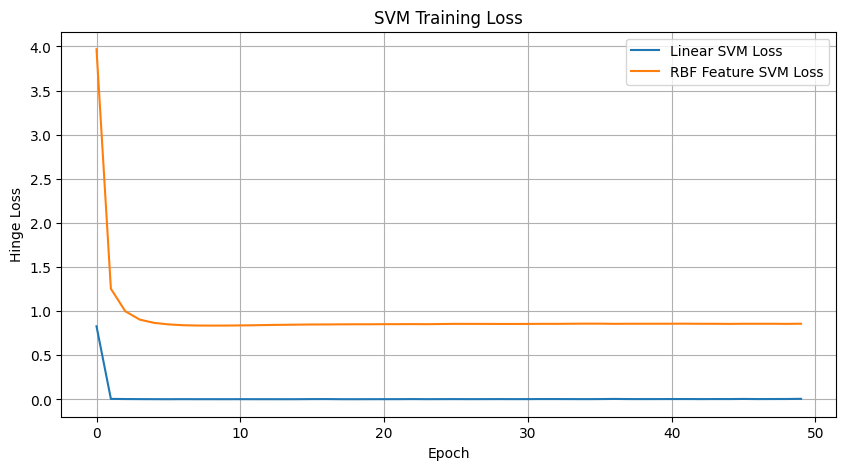

In [25]:
# ============================================================
# 21. 학습 손실 그래프
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 5))

# 선형 SVM 손실 곡선을 그립니다.
plt.plot(linear_loss_history, label="Linear SVM Loss")

# RBF 특징 SVM 손실 곡선을 그립니다.
plt.plot(rbf_loss_history, label="RBF Feature SVM Loss")

# 그래프 제목을 설정합니다.
plt.title("SVM Training Loss")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Hinge Loss")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 10단계. 최종 성능 비교

선형 SVM보다 RBF 커널 SVM의 정확도가 더 높게 나옵니다.
  
선형 모델과 RBF 특징 근사 모델의 정확도를 비교합니다.

In [26]:
# ============================================================
# 22. 선형 SVM과 RBF 특징 SVM 성능 비교
# ============================================================

# 결과를 DataFrame으로 정리합니다.
result_df = pd.DataFrame({
    "Model": ["Linear SVM", "RBF Feature SVM"],
    "Test Accuracy": [linear_acc, rbf_acc]
})

# 결과를 출력합니다.
result_df

,Model,Test Accuracy
0,Linear SVM,0.999619
1,RBF Feature SVM,0.929299


In [27]:

# ============================================================
# 23. 예측 결과 샘플 비교
# ============================================================

# [이전 코드 - letter 라벨 변환]
# true_letters = label_encoder.inverse_transform(y_test)

# [이전 코드 - 우편번호 라벨 변환]
# true_zips = le_zip.inverse_transform(y_test)

# 실제 도이름 라벨을 복원합니다.
true_do = le_do.inverse_transform(y_test)

# 비교할 샘플 개수를 지정합니다.
sample_count = 30

# 실제값, 선형 SVM 예측값, RBF SVM 예측값을 표로 정리합니다.
compare_df = pd.DataFrame({
    "Actual":              true_do[:sample_count],
    "Linear_SVM_Pred":     linear_pred_do[:sample_count],
    "RBF_Feature_SVM_Pred": rbf_pred_do[:sample_count]
})

# 비교 결과를 출력합니다.
compare_df


,Actual,Linear_SVM_Pred,RBF_Feature_SVM_Pred
0,인천광역시,인천광역시,인천광역시
1,충청북도,충청북도,충청북도
2,서울특별시,서울특별시,대구광역시
3,경기도,경기도,경기도
4,경기도,경기도,경기도
5,강원도,강원도,강원도
6,경상남도,경상남도,경상남도
7,광주광역시,광주광역시,광주광역시
8,대전광역시,대전광역시,대전광역시
9,서울특별시,서울특별시,경상북도


In [32]:

# [이전 코드 - letter 라벨 변환]
# true_letters = label_encoder.inverse_transform(y_test)
# classes = label_encoder.classes_

# [이전 코드 - 우편번호 라벨 변환]
# true_zips = le_zip.inverse_transform(y_test)

# 실제 도이름 라벨을 복원합니다.
true_do = le_do.inverse_transform(y_test)

# 비교할 혼동 사례 개수를 지정합니다 (Top 5).
sample_count = 5

classes = np.array(class_names)

# 선형 SVM 상위 혼동 위치 찾기 (temp_cm은 셀 14에서 계산됨)
sorted_indices = np.argsort(temp_cm.ravel())[::-1][:sample_count]
rows, cols = np.unravel_index(sorted_indices, temp_cm.shape)

# RBF SVM 상위 혼동 위치 찾기 (temp_cm_rbf는 셀 19에서 계산됨)
sorted_idx_rbf = np.argsort(temp_cm_rbf.ravel())[::-1][:sample_count]
rows_rbf, cols_rbf = np.unravel_index(sorted_idx_rbf, temp_cm_rbf.shape)

# 선형 SVM과 RBF SVM의 혼동 쌍을 나란히 비교합니다.
compare_df = pd.DataFrame({
    "Linear_Actual":    classes[rows],
    "Linear_Predicted": classes[cols],
    "Linear_count":     temp_cm[rows, cols],
    "RBF_Actual":       classes[rows_rbf],
    "RBF_Predicted":    classes[cols_rbf],
    "RBF_count":        temp_cm_rbf[rows_rbf, cols_rbf]
})

compare_df


,Linear_Actual,Linear_Predicted,Linear_count,RBF_Actual,RBF_Predicted,RBF_count
0,강원도,경기도,4,경기도,서울특별시,36
1,대구광역시,부산광역시,0,서울특별시,경기도,35
2,대구광역시,서울특별시,0,인천광역시,경기도,35
3,대구광역시,세종특별자치시,0,강원도,경기도,27
4,대구광역시,울산광역시,0,경상북도,서울특별시,25


In [34]:
# 1. 먼저 각 모델의 예측 결과가 필요합니다 (이미 있다면 생략 가능)
# linear_preds = (모델 예측 결과), rbf_preds = (모델 예측 결과)

# 2. 테스트 데이터의 실제 주소 텍스트 리스트 (예: df에서 추출한 주소 컬럼)
# 여기서는 'full_address'라는 컬럼이 원본 df에 있다고 가정합니다.
address_test = df['전체주소'].values[16000:] # 테스트 범위만큼 슬라이싱

# 3. 특정 혼동 쌍에 대한 샘플 주소를 가져오는 함수
def get_sample_data(actual_idx, pred_idx, predictions, data_list):
    # 실제값이 actual_idx이고 예측값이 pred_idx인 인덱스 찾기
    mask = (y_test == actual_idx) & (predictions == pred_idx)
    error_indices = np.where(mask)[0]

    if len(error_indices) > 0:
        # 가장 첫 번째 샘플 하나만 반환 (여러 개를 보려면 리스트로 반환 가능)
        return data_list[error_indices[0]]
    return "데이터 없음"

# 4. Top 5 혼동 사례에 대해 샘플 데이터 리스트 생성
linear_samples = [get_sample_data(rows[i], cols[i], linear_preds, address_test) for i in range(sample_count)]
rbf_samples = [get_sample_data(rows_rbf[i], cols_rbf[i], rbf_preds, address_test) for i in range(sample_count)]

# 5. 최종 데이터프레임 생성 (내용 추가)
compare_df = pd.DataFrame({
    "Linear_Actual":    classes[rows],
    "Linear_Predicted": classes[cols],
    "Linear_count":     temp_cm[rows, cols],
    "Linear_Sample":    linear_samples,     # <-- 선형 모델 실제 오답 주소 샘플 추가
    "RBF_Actual":       classes[rows_rbf],
    "RBF_Predicted":    classes[cols_rbf],
    "RBF_count":        temp_cm_rbf[rows_rbf, cols_rbf],
    "RBF_Sample":       rbf_samples         # <-- RBF 모델 실제 오답 주소 샘플 추가
})

compare_df

,Linear_Actual,Linear_Predicted,Linear_count,Linear_Sample,RBF_Actual,RBF_Predicted,RBF_count,RBF_Sample
0,강원도,경기도,4,충청남도 서천군 장항읍 장암리,경기도,서울특별시,36,세종특별자치시 전동면 노장리
1,대구광역시,부산광역시,0,데이터 없음,서울특별시,경기도,35,강원도 원주시 신림면 용암리
2,대구광역시,서울특별시,0,데이터 없음,인천광역시,경기도,35,충청남도 공주시 월송동
3,대구광역시,세종특별자치시,0,데이터 없음,강원도,경기도,27,대전광역시 서구 관저2동 구봉마을5단지 (501~513동)
4,대구광역시,울산광역시,0,데이터 없음,경상북도,서울특별시,25,충청남도 논산시 벌곡면 조령리


# 과제 1

In [40]:
def get_full_addresses(zip_list):
    """
    우편번호 리스트를 입력받아 해당하는 전체 주소 리스트를 반환합니다.
    """
    # 문자열 또는 숫자 입력을 모두 숫자로 변환하여 검색
    zips_to_search = [int(z) for z in zip_list]

    # 원본 데이터프레임에서 해당 우편번호 필터링
    matched_df = df[df['우편번호'].isin(zips_to_search)][['우편번호', '도이름', '전체주소']]

    if matched_df.empty:
        return "검색된 주소가 없습니다."

    return matched_df.reset_index(drop=True)

# --- 여러 우편번호 입력 테스트 ---
input_zips = ['137926', '137930', '487839']
address_results = get_full_addresses(input_zips)

display(address_results)

,우편번호,도이름,전체주소
0,137926,서울특별시,서울특별시 서초구 서초1동 1641-1~1641-13
1,137930,서울특별시,서울특별시 서초구 반포1동 반포자이아파트 (101~144동)
2,487839,경기도,경기도 포천시 관인면 초과리 사서함 105-3
3,487839,경기도,경기도 포천시 관인면 초과리 사서함 105-5
4,487839,강원도,강원도 철원군 동송읍 장흥리 사서함 105-29
5,487839,강원도,강원도 철원군 동송읍 이평7리 사서함 105-22
6,487839,강원도,강원도 철원군 동송읍 이평2리 사서함 105-13
7,487839,강원도,강원도 철원군 동송읍 오지리 사서함 105-2
8,487839,강원도,강원도 철원군 동송읍 오지리 사서함 105-9
9,487839,강원도,강원도 철원군 동송읍 오지리 사서함 105-23


# 과제 2

In [43]:
def find_zip_codes_by_address_list(address_list):
    """
    주소 키워드 리스트를 입력받아 해당하는 우편번호와 전체 주소를 반환합니다.
    """
    # 리스트 내의 키워드들을 정규표현식(OR 조건)으로 결합
    pattern = '|'.join(address_list)

    # '전체주소' 컬럼에서 해당 패턴이 포함된 데이터 필터링
    matched_df = df[df['전체주소'].str.contains(pattern, na=False, case=False)]

    if matched_df.empty:
        return "검색된 결과가 없습니다."

    # 우편번호와 전체주소 정보 위주로 반환
    return matched_df[['우편번호', '도이름', '시군구이름', '전체주소']].reset_index(drop=True)

# --- 주소 리스트 검색 테스트 ---
# 찾고 싶은 주소 키워드들을 리스트로 입력하세요.
my_address_keywords = ['서초동', '관인면']
search_results = find_zip_codes_by_address_list(my_address_keywords)

print(f"주소 키워드 {my_address_keywords} 검색 결과:")
display(search_results)

주소 키워드 ['서초동', '관인면'] 검색 결과:


,우편번호,도이름,시군구이름,전체주소
0,137070,서울특별시,서초구,서울특별시 서초구 서초동
1,487839,경기도,포천시,경기도 포천시 관인면 초과리 사서함 105-3
2,487839,경기도,포천시,경기도 포천시 관인면 초과리 사서함 105-5
3,487839,경기도,포천시,경기도 포천시 관인면 사정리 사서함 105-29
4,487839,경기도,포천시,경기도 포천시 관인면 사정리 사서함 105-1
5,487839,경기도,포천시,경기도 포천시 관인면 사정리 사서함 105-7
6,487839,경기도,포천시,경기도 포천시 관인면 사정리 사서함 105-8
7,487839,경기도,포천시,경기도 포천시 관인면 사정리 사서함 105-28
8,487839,경기도,포천시,경기도 포천시 관인면 사정리 사서함 105-12
9,487930,경기도,포천시,경기도 포천시 관인면


In [ ]:
def get_addresses_by_zip_list(zip_list):
    """
    우편번호 리스트를 입력받아 해당하는 전체 주소 정보를 반환합니다.
    """
    # 문자열 리스트일 경우를 대비해 숫자로 변환
    zip_numbers = [int(z) for z in zip_list]

    # 우편번호 컬럼에서 해당 번호들을 필터링
    result = df[df['우편번호'].isin(zip_numbers)][['우편번호', '도이름', '시군구이름', '전체주소']]

    if result.empty:
        return "해당 우편번호들에 대한 주소 데이터를 찾을 수 없습니다."

    return result.reset_index(drop=True)

# --- 우편번호 리스트 검색 테스트 ---
test_zips = ['137926', '137930', '487839']
address_results = get_addresses_by_zip_list(test_zips)

print(f"우편번호 {test_zips} 검색 결과:")
display(address_results)